# Environment Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')
%cd /content/drive/MyDrive/spinal-bone-feature-detection
!ls

Mounted at /content/drive/
/content/drive/MyDrive/spinal-bone-feature-detection
best_faster_rcnn.pth  best_rpn.pth	mmdetection.ipynb   Spinal_RTDETR_42_8
best_mAP50.pth	      config.yaml	results		    Spinal_YOLOv11_42_8
best_mAP75.pth	      datasets		results_CIoU
best_model.pth	      FasterRCNN.ipynb	results_DIoU
best_resnet.pth       GNN.ipynb		results_FasterRCNN


In [ ]:
!unzip -q ./datasets/ultrasound.zip -d /tmp/ultrasound
!pip install -q torchmetrics[detection]
# !pip install -q torch_geometric

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 29.5 MB/s eta 0:00:00


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter

from torchvision.models import resnet18, ResNet18_Weights
from torchvision.ops import RoIAlign, distance_box_iou_loss, box_iou
from torchmetrics.functional.detection.map import mean_average_precision
from torchmetrics.detection.mean_ap import MeanAveragePrecision

import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.metrics import classification_report, precision_recall_curve, confusion_matrix, roc_curve, auc
from scipy.optimize import linear_sum_assignment
from scipy.interpolate import CubicSpline

import yaml
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as patches

from collections import OrderedDict
from tqdm.notebook import tqdm
from pathlib import Path
from PIL import Image

In [ ]:
%load_ext tensorboard
!rm -rf results
plt.style.use('seaborn-v0_8')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Data Loading

In [ ]:
class ScoliosisDataset(Dataset):
    def __init__(self, split='train', config_path='config.yaml'):
        # Initialize the dataset for a given split (train/val)
        with open(config_path, 'r') as f:
            self.config = yaml.safe_load(f)

        self.split = split
        self.processed_images_dir = Path(self.config['data']['processed_images_dir'])
        self.processed_annotations_dir = Path(self.config['data']['processed_annotations_dir'])
        self.metadata_dir = Path(self.config['data']['metadata_dir'])
        with open(self.metadata_dir / 'splits.yaml', 'r') as f:
            splits = yaml.safe_load(f)

        self.image_names = splits[split]  # List of image names for the split
        self.means = np.array(splits['mean'], dtype=np.float32)  # Shape: (2,)
        self.stds = np.array(splits['std'], dtype=np.float32)    # Shape: (2,)
        self.transforms = self.get_transforms()


    def get_transforms(self):
        speckle_noise_std = self.config['augmentation']['speckle_noise_std']
        elastic_alpha = self.config['augmentation']['elastic_alpha']
        elastic_sigma = self.config['augmentation']['elastic_sigma']
        contrast_range = self.config['augmentation']['contrast_range']
        brightness_range = self.config['augmentation']['brightness_range']

        if self.split == 'train': # Apply augmentation if training
            return A.Compose([
                A.GaussNoise(std_range=(speckle_noise_std, speckle_noise_std), mean_range=(0.0, 0.0), per_channel=True, p=0.5),
                A.ElasticTransform(alpha=elastic_alpha, sigma=elastic_sigma, approximate=False, p=0.5),
                A.RandomBrightnessContrast(brightness_limit=brightness_range, contrast_limit=contrast_range, p=0.5),
                A.Rotate(limit=10, p=0.5), # Small angles to avoid disrupting anatomical structure
                A.Normalize(mean=self.means, std=self.stds, max_pixel_value=1.0, p=1.0), # Ensure pixel values stay in [0, 1]
                ToTensorV2(p=1.0), # Convert to PyTorch tensor
            ], bbox_params=A.BboxParams(
                format='pascal_voc', # [x_min, y_min, x_max, y_max]
                label_fields=['labels'],  # Pass additional labels
                min_area=1,  # Drop boxes smaller than 1 pixels after augmentation
                min_visibility=0.3  # Discard boxes with less than 30% visibility after augmentation
            ))
        return A.Compose([
            A.Normalize(mean=self.means, std=self.stds, max_pixel_value=1.0, p=1.0), # Only normalization for validation
            ToTensorV2(p=1.0) # Convert to PyTorch tensor
        ])


    def __len__(self):
        return len(self.image_names)

    def __getitem__(self, idx):
        image_name = self.image_names[idx]
        image = np.load(self.processed_images_dir / f'{image_name}.npy') # Shape: (H, W, 2)

        # Load annotations
        with open(self.processed_annotations_dir / f'{image_name}.txt', 'r') as f:
            annotations = [line.strip().split() for line in f.readlines()]
        annotations = np.array(annotations, dtype=np.float32) # Shape: (num_boxes, 5)

        # Extract boxes and labels
        boxes = annotations[:, 1:5] # x_min, y_min, x_max, y_max
        labels = annotations[:, 0].astype(np.int64) # 0: Thoracic, 1: Lumbar

        # Apply transformations
        transformed = self.transforms(image=image, bboxes=boxes, labels=labels)
        image = transformed['image']
        boxes = torch.tensor(transformed['bboxes'], dtype=torch.float32)   # Shape: (num_boxes, 4)
        labels = torch.tensor(transformed['labels'], dtype=torch.int64)   # Shape: (num_boxes,)
        return image_name, image, {'boxes': boxes, 'labels': labels}

In [ ]:
def collate_fn(batch):
    names, images, targets = zip(*batch)
    images = torch.stack(images, dim=0)  # Shape: (batch_size, 2, H, W)
    return list(names), images, list(targets)  # Targets as a list of dictionaries


def get_loader(split='train', config_path='config.yaml', batch_size=32):
    # Create a data loader for a specific split (train/val)
    dataset = ScoliosisDataset(split=split, config_path=config_path)
    return DataLoader(
        dataset, batch_size=batch_size,
        shuffle=True if split == 'train' else False, num_workers=2,
        pin_memory=True, collate_fn=collate_fn
    )

In [ ]:
train_loader, val_loader = get_loader('train', batch_size=32), get_loader('val', batch_size=1)
print(f'Train loader: {len(train_loader.dataset)} samples')
print(f'Val loader: {len(val_loader.dataset)} samples')

for names, images, targets in train_loader:
    print(f'Batch images shape: {images.shape}')
    for names, target in zip(names, targets):
        print(f"{names}: boxes={target['boxes'].shape}, labels={target['labels'].shape}")
    break

Train loader: 42 samples
Val loader: 8 samples
Batch images shape: torch.Size([32, 2, 448, 224])
PWH00200113720160111000P3: boxes=torch.Size([28, 4]), labels=torch.Size([28])
PWH00200118820160122006P4: boxes=torch.Size([24, 4]), labels=torch.Size([24])
PWH00200120420160128003P5: boxes=torch.Size([26, 4]), labels=torch.Size([26])
PWH00200119720160127000P6: boxes=torch.Size([24, 4]), labels=torch.Size([24])
PWH00200119120160122009P5: boxes=torch.Size([26, 4]), labels=torch.Size([26])
PWH00200118520160122003P4: boxes=torch.Size([24, 4]), labels=torch.Size([24])
PWH00200117920160121002P6: boxes=torch.Size([26, 4]), labels=torch.Size([26])
PWH00200117820160121001P3: boxes=torch.Size([28, 4]), labels=torch.Size([28])
PWH00200114020160111003P5: boxes=torch.Size([27, 4]), labels=torch.Size([27])
PWH00200120220160128001P5: boxes=torch.Size([28, 4]), labels=torch.Size([28])
PWH00200114920160113006P5: boxes=torch.Size([27, 4]), labels=torch.Size([27])
PWH00200116120160115004P5: boxes=torch.Size([

# Model Implementation

## GNN Components

In [ ]:
class EdgeNet(nn.Module):
    def __init__(self, in_features, num_features, device, ratio=(1,)):
        super(EdgeNet, self).__init__()
        num_features_list = [num_features * r for r in ratio]
        layer_list = OrderedDict()
        self.device = device

        for l in range(len(num_features_list)):
            layer_list['conv%d' % l] = nn.Conv2d(
                in_channels = num_features_list[l - 1] if l > 0 else in_features,
                out_channels = num_features_list[l],
                kernel_size = 1, bias = False
            )
            layer_list['norm%d' % l] = nn.BatchNorm2d(num_features=num_features_list[l])
            layer_list['relu%d' % l] = nn.LeakyReLU()

        # Add final similarity kernel
        layer_list['conv_out'] = nn.Conv2d(in_channels=num_features_list[-1], out_channels=1, kernel_size=1)
        self.sim_network = nn.Sequential(layer_list).to(device)


    def forward(self, node_feat):
        node_feat = node_feat.unsqueeze(dim=0) # (1, bs, dim)
        num_tasks = node_feat.size(0) # 1
        num_data = node_feat.size(1) # bs

        x_i = node_feat.unsqueeze (2) # (1, bs, 1, dim)
        x_j = torch.transpose(x_i, 1, 2) # (1, 1, bs, dim)
        x_ij = torch.abs(x_i - x_j) # (1, bs, bs, dim)
        x_ij = torch.transpose(x_ij, 1, 3) # (1, dim, bs, bs)

        # Compute similarity / dissimilarity (batch_size x feat_size x num_samples x num_samples)
        sim_val = (torch.sigmoid(self.sim_network(x_ij)).squeeze(1).squeeze(0).to(self.device)) # (bs, bs)

        # Normalize affinity matrix
        force_edge_feat = (torch.eye(num_data).unsqueeze(0).repeat(num_tasks, 1, 1).to(self.device)) # (1, bs, bs)
        edge_feat = sim_val + force_edge_feat # (bs, bs)
        edge_feat = edge_feat + 1e-6 # Add small value to avoid nan
        edge_feat = edge_feat / torch.sum(edge_feat, dim =1).unsqueeze (1) # Normalize
        return edge_feat, sim_val # (bs, bs), (bs, bs)


class NodeNet(nn.Module):
    def __init__(self, in_features, num_features, device, ratio =(1,)):
        super(NodeNet, self).__init__()
        num_features_list = [num_features * r for r in ratio]
        layer_list = OrderedDict()
        self.device = device

        for l in range(len(num_features_list)):
            layer_list['conv%d' % l] = nn.Conv2d(
                in_channels = num_features_list[l - 1] if l > 0 else in_features * 2,
                out_channels = num_features_list[l],
                kernel_size = 1,
                bias = False,
            )
            layer_list['norm%d' % l] = nn.BatchNorm2d(num_features=num_features_list[l])

            if l < len(num_features_list) - 1: layer_list['relu%d' % l] = nn.LeakyReLU()
        self.network = nn.Sequential(layer_list).to(device)


    def forward(self, node_feat, edge_feat):
        # node_feat: (bs, dim), edge_feat: (bs, bs)
        node_feat = node_feat.unsqueeze(dim=0) # (1, bs, dim)
        num_tasks = node_feat.size(0) # 1
        num_data = node_feat.size(1) # bs

        # Get eye matrix(batch_size x node_size x node_size) only use inter dist.
        diag_mask = 1.0 - torch.eye(num_data).unsqueeze(0).repeat(num_tasks, 1, 1).to(self.device) # (1, bs, bs)

        # Set diagonal as zero and normalize
        edge_feat = F.normalize(edge_feat * diag_mask, p=1, dim=-1) # (bs, bs)

        # Compute attention and aggregate
        aggr_feat = torch.bmm(edge_feat.squeeze(1), node_feat) # (bs, dim)
        node_feat = torch.cat([node_feat, aggr_feat], -1).transpose(1, 2) # (1, 2 * dim, bs)

        # Non-linear transform
        node_feat = self.network(node_feat.unsqueeze(-1)).transpose(1, 2) # (1, bs, dim)
        return node_feat.squeeze(-1).squeeze(0) # (bs, dim)

In [ ]:
class GNN(nn.Module):
    def __init__(self, in_features, edge_features, out_features, device, ratio=(1,)):
        super(GNN, self).__init__()
        self.edge_net = EdgeNet(in_features=in_features, num_features=edge_features, device=device, ratio=ratio)
        self.node_net = NodeNet(in_features=in_features, num_features=out_features, device=device, ratio=ratio) # Set edge to node
        self.mask_val = -1 # mask value for no-gradient edges

    def label2edge(self, targets): # Convert node labels to affinity mask for backprop
        num_sample = targets.size()[1]
        label_i = targets.unsqueeze(-1).repeat(1, 1, num_sample)
        label_j = label_i.transpose(1, 2)
        edge = torch.eq(label_i, label_j).float()
        target_edge_mask = (torch.eq(label_i, self.mask_val) + torch.eq(label_j, self.mask_val)).type(torch.bool)
        source_edge_mask = ~target_edge_mask
        edge *= source_edge_mask.float()
        return edge[0], source_edge_mask

    def forward(self, node_feat):
        edge_feat, edge_sim = self.edge_net(node_feat) # Compute normalized and not normalized affinity matrix
        logits_gnn = self.node_net(node_feat, edge_feat) # Get edge feature and class logits
        return logits_gnn, edge_sim

## Multi-Task GNN-based Model

In [ ]:
class MultiTaskModel(nn.Module):
    def __init__(self, num_classes=2):
        super(MultiTaskModel, self).__init__()
        self.backbone = nn.Sequential(*list(resnet18().children())[:-2]) # Remove avgpool and fc layers
        self.backbone[0] = nn.Conv2d(in_channels=2, out_channels=64, kernel_size=7, stride=2, padding=3, bias=False)
        self.backbone2roi_proj = nn.Conv2d(in_channels=512, out_channels=64, kernel_size=1)

        self.roi_align = RoIAlign(output_size=(5, 5), spatial_scale=1.0 / 32.0, sampling_ratio=-1)
        self.gnn = GNN(in_features=64 * 5 * 5, edge_features=512, out_features=num_classes, device=device, ratio=(1,))
        self.box_regressor = nn.Sequential(
            nn.Linear(64 * 5 * 5, 256),
            nn.ReLU(),
            nn.Linear(256, 4)
        )

    def forward(self, images, all_boxes, boxes_by_images):
        feature_maps = self.backbone(images) # Shape: (batch_size, 512, H/32, W/32)
        feature_maps = self.backbone2roi_proj(feature_maps) # Shape: (batch_size, 64, H/32, W/32)

        # Create batch indices for each box
        batch_indices = torch.cat([
            torch.full((len(b),), i, dtype=torch.int64)
            for i, b in enumerate(boxes_by_images)
        ], dim=0).to(images.device) # Shape: (total_boxes,)

        # Combine batch_indices and all_boxes into a single rois tensor
        rois = torch.cat([batch_indices.unsqueeze(1).float(), all_boxes], dim=1) # Shape: (total_boxes, 5)

        # Apply RoIAlign and flatten the pooled features
        pooled_features = self.roi_align(feature_maps, rois) # Shape: (total_boxes, 64, 5, 5)
        pooled_features = pooled_features.view(pooled_features.size(0), -1)  # Shape: (total_boxes, 64 * 5 * 5)

        pred_boxes = self.box_regressor(pooled_features)
        pred_labels, edge_sim = self.gnn(pooled_features)
        return pred_boxes, pred_labels, edge_sim

# Model Training

In [ ]:
def concat_batch(images, targets, device):
    images = images.to(device)
    boxes_by_images, labels_by_images, all_labels = [], [], []
    for target in targets:
        target['boxes'] = target['boxes'].to(device)
        target['labels'] = target['labels'].to(device)
        boxes_by_images.append(target['boxes'])
        labels_by_images.append(target['labels'])

    all_boxes = torch.cat(boxes_by_images, dim=0)
    all_labels = torch.cat(labels_by_images, dim=0)
    return images, targets, boxes_by_images, labels_by_images, all_boxes, all_labels

## Training Utilities

In [ ]:
def compute_losses(images, targets, criterion_box, criterion_cls, criterion_edge, device):
    images, targets, boxes_by_images, labels_by_images, all_boxes, all_labels = concat_batch(images, targets, device)
    pred_boxes, pred_labels, edge_sim = model(images, targets, boxes_by_images)

    # Calculate Multi-task loss (same as before)
    box_loss = criterion_box(pred_boxes, all_boxes, reduction='mean')  # Box loss
    cls_loss = criterion_cls(pred_labels, all_labels)  # Cls loss
    edge_gt, edge_mask = model.gnn.label2edge(all_labels.unsqueeze(dim=0))
    edge_loss = criterion_edge(
        edge_sim.masked_select(edge_mask), edge_gt.masked_select(edge_mask)
    )
    return cls_loss, box_loss, edge_loss, all_boxes, all_labels, pred_boxes, pred_labels

In [ ]:
def train_model(model, train_loader, val_loader, optimizer, num_epochs, device):
    # Train a multi-task model for object detection and clustering
    writer = SummaryWriter('./results')
    history = {
        'train_total_losses': [], 'train_cls_losses': [], 'train_box_losses': [], 'train_edge_losses': [],
        'val_total_losses': [], 'val_cls_losses': [], 'val_box_losses': [], 'val_edge_losses': [],
    }
    best_val_total_loss = torch.inf
    criterion_box, criterion_cls, criterion_edge = distance_box_iou_loss, nn.CrossEntropyLoss(), nn.BCELoss()

    # scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr=3e-4, epochs=num_epochs, steps_per_epoch=len(train_loader), pct_start=0.1)
    for epoch in range(num_epochs): # Training loop
        # loop = tqdm(enumerate(train_loader), total=total_batches)
        train_total_loss, train_cls_loss, train_box_loss, train_edge_loss = 0, 0, 0, 0
        # mAP_preds, mAP_targets = [], []
        total_batches = len(train_loader)
        model.train()

        # Iterate over training batches
        for batch_idx, (_, images, targets) in enumerate(train_loader):
            cls_loss, box_loss, edge_loss, all_boxes, all_labels, pred_boxes, pred_labels = \
            compute_losses(images, targets, criterion_box, criterion_cls, criterion_edge, device)

            # Aggregate losses
            total_loss = cls_loss + box_loss + edge_loss
            train_cls_loss += cls_loss.item()
            train_box_loss += box_loss.item()
            train_edge_loss += edge_loss.item()
            train_total_loss += total_loss.item()

            # Prepare for mAP calculation
            # pred_labels = F.softmax(pred_labels, dim=-1)
            # scores, pred_labels_idxs = pred_labels.max(dim=1)
            # mAP_preds.append({"boxes": pred_boxes, "scores": scores, "labels": pred_labels_idxs})
            # mAP_targets.append({"boxes": all_boxes, "labels": all_labels})

            # Backward pass and optimization
            optimizer.zero_grad() # Zero gradients
            total_loss.backward()
            optimizer.step()
            # scheduler.step()

            # Update the progress bar
            # loop.set_description(f"[EPOCH {epoch+1}/{num_epochs}] {batch_idx + 1}/{total_batches}")
            # loop.set_postfix(loss=total_loss.item(), accuracy=(correct / total).item())
            # loop.update()

        train_cls_loss /= total_batches
        train_box_loss /= total_batches
        train_edge_loss /= total_batches
        train_total_loss /= total_batches
        # train_mAPs = mean_average_precision(mAP_preds, mAP_targets, class_metrics=True)

        history['train_cls_losses'].append(train_cls_loss)
        history['train_box_losses'].append(train_box_loss)
        history['train_edge_losses'].append(train_edge_loss)
        history['train_total_losses'].append(train_total_loss)

        # Validation
        val_total_loss, val_cls_loss, val_box_loss, val_edge_loss, val_mAPs = evaluate_model(model, val_loader, device)
        history['val_cls_losses'].append(val_cls_loss)
        history['val_box_losses'].append(val_box_loss)
        history['val_edge_losses'].append(val_edge_loss)
        history['val_total_losses'].append(val_total_loss)

        # Print all the results
        print(
            f"[EPOCH {epoch+1}/{num_epochs}] "
            f"Train Loss: {train_total_loss:.4f} (CLS: {train_cls_loss:.4f}, BOX: {train_box_loss:.4f}, EDGE: {train_edge_loss:.4f})"
            # f" - Train mAP@0.5: {train_mAPs['map_50']:.4f}"
            f" - Val Loss: {val_total_loss:.4f} (CLS: {val_cls_loss:.4f}, BOX: {val_box_loss:.4f}, EDGE: {val_edge_loss:.4f})"
            # f" - Val mAP@0.5: {val_mAPs['map_50']:.4f}"
            # f" - LR: {scheduler.get_last_lr()[0]:.6f}"
        )
        writer.add_scalars('Loss/Total', {'train': train_total_loss, 'val': val_total_loss}, epoch)
        writer.add_scalars('Loss/CLS', {'train': train_cls_loss, 'val': val_cls_loss}, epoch)
        writer.add_scalars('Loss/BOX', {'train': train_box_loss, 'val': val_box_loss}, epoch)
        writer.add_scalars('Loss/EDGE', {'train': train_edge_loss, 'val': val_edge_loss}, epoch)

        # Save the best model based on validation loss
        if val_total_loss < best_val_total_loss:
            best_val_total_loss = val_total_loss
            torch.save(model.state_dict(), 'best_model.pth')
    return history

In [ ]:
def evaluate_model(model, val_loader, device):
    criterion_box, criterion_cls, criterion_edge = distance_box_iou_loss, nn.CrossEntropyLoss(), nn.BCELoss()
    val_total_loss, val_cls_loss, val_box_loss, val_edge_loss = 0, 0, 0, 0
    # mAP_preds, mAP_targets = [], []
    total_batches = len(val_loader)
    # model.eval()

    with torch.no_grad():
        for _, images, targets in val_loader:
            cls_loss, box_loss, edge_loss, all_boxes, all_labels, pred_boxes, pred_labels = \
            compute_losses(images, targets, criterion_box, criterion_cls, criterion_edge, device)

            # Aggregate losses
            total_loss = cls_loss + box_loss + edge_loss
            val_cls_loss += cls_loss.item()
            val_box_loss += box_loss.item()
            val_edge_loss += edge_loss.item()
            val_total_loss += total_loss.item()

            # Prepare for mAP calculation
            # pred_labels = F.softmax(pred_labels, dim=-1)
            # scores, pred_labels_idxs = pred_labels.max(dim=1)
            # mAP_preds.append({"boxes": pred_boxes, "scores": scores, "labels": pred_labels_idxs})
            # mAP_targets.append({"boxes": all_boxes, "labels": all_labels})

    val_cls_loss /= total_batches
    val_box_loss /= total_batches
    val_edge_loss /= total_batches
    val_total_loss /= total_batches
    mAPs = {} # mean_average_precision(mAP_preds, mAP_targets, class_metrics=True)
    return val_total_loss, val_cls_loss, val_box_loss, val_edge_loss, mAPs

## Experiment

In [ ]:
train_loader, val_loader = get_loader('train', batch_size=16), get_loader('val', batch_size=1)
model = MultiTaskModel().to(device)
optimizer = optim.AdamW(model.parameters(), lr=2e-4)

In [ ]:
%%time
import gc
gc.collect()
torch.cuda.empty_cache()
history = train_model(model, train_loader, val_loader, optimizer, num_epochs=1000, device=device)

[EPOCH 1/1000] Train Loss: 3.1956 (CLS: 0.7453, BOX: 1.7731, EDGE: 0.6772) - Val Loss: 3.0080 (CLS: 0.6368, BOX: 1.7351, EDGE: 0.6361)
[EPOCH 2/1000] Train Loss: 2.9579 (CLS: 0.6159, BOX: 1.7293, EDGE: 0.6127) - Val Loss: 2.8704 (CLS: 0.6164, BOX: 1.6871, EDGE: 0.5668)
[EPOCH 3/1000] Train Loss: 2.8344 (CLS: 0.5683, BOX: 1.6840, EDGE: 0.5821) - Val Loss: 2.7540 (CLS: 0.5736, BOX: 1.6388, EDGE: 0.5416)
[EPOCH 4/1000] Train Loss: 2.7824 (CLS: 0.5680, BOX: 1.6375, EDGE: 0.5769) - Val Loss: 2.6635 (CLS: 0.5481, BOX: 1.5868, EDGE: 0.5286)
[EPOCH 5/1000] Train Loss: 2.6733 (CLS: 0.5359, BOX: 1.5872, EDGE: 0.5502) - Val Loss: 2.6754 (CLS: 0.5754, BOX: 1.5276, EDGE: 0.5725)
[EPOCH 6/1000] Train Loss: 2.5855 (CLS: 0.5122, BOX: 1.5276, EDGE: 0.5458) - Val Loss: 2.6382 (CLS: 0.5925, BOX: 1.4646, EDGE: 0.5811)
[EPOCH 7/1000] Train Loss: 2.4971 (CLS: 0.5072, BOX: 1.4611, EDGE: 0.5288) - Val Loss: 2.5655 (CLS: 0.5791, BOX: 1.4038, EDGE: 0.5826)
[EPOCH 8/1000] Train Loss: 2.4269 (CLS: 0.5082, BOX: 1.

In [ ]:
%tensorboard --logdir results

# Evaluation

## mAP, CF Matrix, PR Curve

{'map': tensor(0.5286),
 'map_50': tensor(0.9765),
 'map_75': tensor(0.5394),
 'map_small': tensor(0.5277),
 'map_medium': tensor(0.5371),
 'map_large': tensor(-1.),
 'mar_1': tensor(0.0667),
 'mar_10': tensor(0.4585),
 'mar_100': tensor(0.6230),
 'mar_small': tensor(0.6020),
 'mar_medium': tensor(0.6471),
 'mar_large': tensor(-1.),
 'map_per_class': tensor([0.5213, 0.5359]),
 'mar_100_per_class': tensor([0.6289, 0.6170]),
 'classes': tensor([0, 1], dtype=torch.int32)}

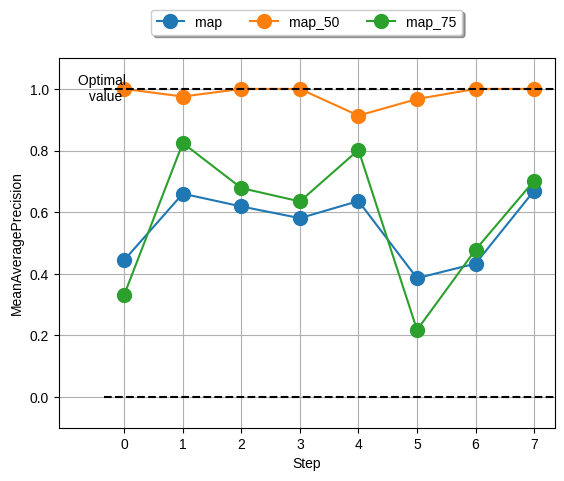

In [ ]:
checkpoint = torch.load('best_mAP50.pth')
model = MultiTaskModel().to(device)
model.load_state_dict(checkpoint)
model.eval()

with torch.no_grad():
    metric = MeanAveragePrecision(class_metrics=True)
    mAP_by_step, mAP_preds, mAP_targets = [], [], []

    for _, images, targets in val_loader:
        images, targets, boxes_by_images, labels_by_images, all_boxes, all_labels = concat_batch(images, targets, device)
        pred_boxes, pred_labels, _ = model(images, all_boxes, boxes_by_images)
        pred_labels = F.softmax(pred_labels, dim=-1)
        scores, pred_labels_idxs = pred_labels.max(dim=1)

        mAP_preds.append({'boxes': pred_boxes, 'scores': scores, 'labels': pred_labels_idxs})
        mAP_targets.append({'boxes': all_boxes, 'labels': all_labels})
        mAP_dict = metric([mAP_preds[-1]], [mAP_targets[-1]])

        # Remove keys started with mar or with classes
        mAP_dict = {k: v for k, v in mAP_dict.items() if k in ['map', 'map_50', 'map_75']}
        mAP_by_step.append(mAP_dict)

metric.plot(mAP_by_step)
{k: v for k, v in mean_average_precision(mAP_preds, mAP_targets, class_metrics=True).items()}

In [ ]:
def plot_cf_matrix(cf_matrix, label_names, ax=None):
    labels = np.asarray([f'{name}\n{count:,}\n{percent:.2%}' for name, count, percent in zip(
        ['True Neg', 'False Pos', 'False Neg', 'True Pos'], # Group names
        cf_matrix.flatten(), # Group counts
        cf_matrix.flatten() / np.sum(cf_matrix) # Group percentages
    )]).reshape(2, 2)
    sns.heatmap(
        cf_matrix, fmt='', annot=labels,
        cmap='YlGnBu', square=True, annot_kws={'size': 12},
        xticklabels=label_names, yticklabels=label_names, ax=ax
    )

all_preds, all_targets = [], []
for pred, target in zip(mAP_preds, mAP_targets):
    all_preds.extend(pred['labels'].cpu().numpy())
    all_targets.extend(target['labels'].cpu().numpy())

              precision    recall  f1-score   support

    Thoracic       1.00      1.00      1.00       159
      Lumbar       1.00      1.00      1.00        47

    accuracy                           1.00       206
   macro avg       1.00      1.00      1.00       206
weighted avg       1.00      1.00      1.00       206



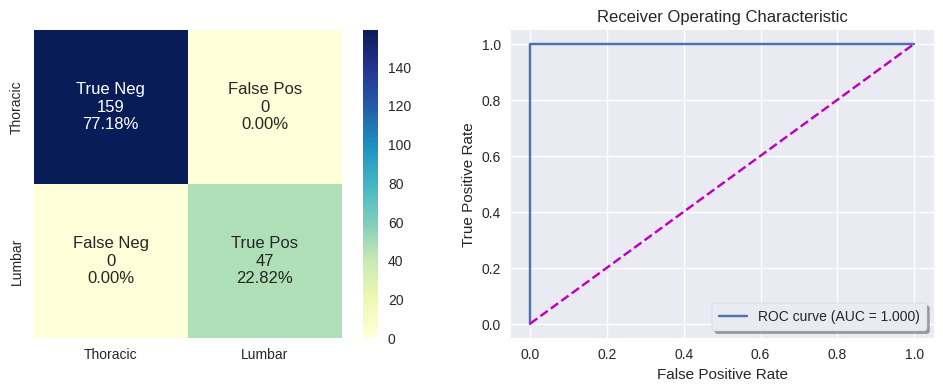

In [ ]:
label_names=['Thoracic', 'Lumbar']
print(classification_report(all_targets, all_preds, target_names=label_names))
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
cm = confusion_matrix(all_targets, all_preds)
plot_cf_matrix(cm, label_names=label_names)

plt.subplot(1, 2, 2)
fpr, tpr, _ = roc_curve(all_targets, all_preds)
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc(fpr, tpr):.3f})')
plt.plot([0, 1], [0, 1], 'm--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right', frameon=True, shadow=True, borderpad=0.5)
plt.show()

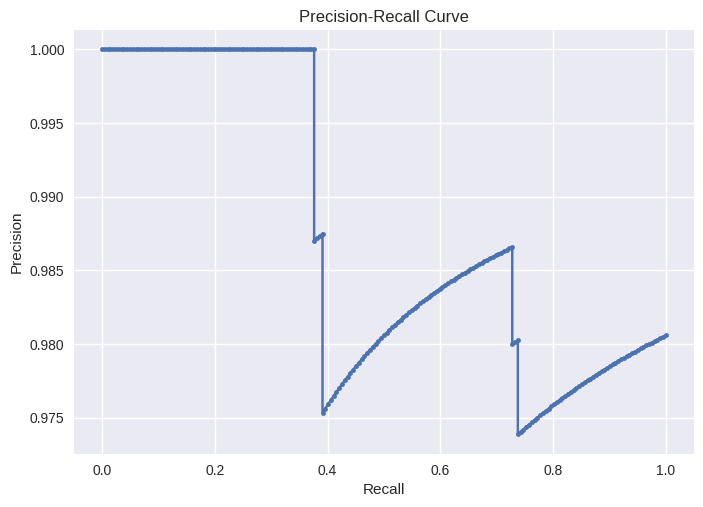

In [ ]:
def compute_pr_curve(preds, targets, iou_threshold=0.5): # Evaluate predictions and compute PR curve
    all_scores, all_labels = [], [] # 1 for TP, 0 for FP
    for pred, target in zip(preds, targets):
        pred_boxes = pred['boxes']   # [N, 4]
        scores = pred['scores']      # [N]
        pred_labels = pred['labels'] # [N]
        gt_boxes = target['boxes']   # [M, 4]
        gt_labels = target['labels'] # [M]
        if len(pred_boxes) == 0 or len(gt_boxes) == 0: continue

        # Compute IoU between all pred and gt boxes
        iou = box_iou(pred_boxes, gt_boxes).cpu().numpy()  # [N, M]
        max_iou = np.max(iou, axis=1)  # Best IoU for each prediction
        matched_idx = np.argmax(iou, axis=1)

        # For each prediction, determine if it's a TP or FP
        for i, (score, pred_label) in enumerate(zip(scores, pred_labels)):
            if max_iou[i] >= iou_threshold:
                gt_idx = matched_idx[i]
                if pred_label == gt_labels[gt_idx]: all_labels.append(1)  # True Positive
                else: all_labels.append(0)  # False Positive (wrong label)
            else: all_labels.append(0)  # False Positive (no match)
            all_scores.append(score.cpu().numpy())

    # Sort by scores in descending order
    all_scores = np.array(all_scores)
    all_labels = np.array(all_labels)
    order = np.argsort(all_scores)[::-1]
    all_scores = all_scores[order]
    all_labels = all_labels[order]

    # Compute precision and recall
    precision, recall, _ = precision_recall_curve(all_labels, all_scores)
    return precision, recall

precision, recall = compute_pr_curve(mAP_preds, mAP_targets)
plt.plot(recall, precision, marker='.')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(True)
plt.show()

## Display Validation Inference

In [ ]:
checkpoint = torch.load('best_mAP50.pth')
model = MultiTaskModel().to(device)
model.load_state_dict(checkpoint)
model.eval()

with open('config.yaml', 'r') as f:
    config = yaml.safe_load(f)
    images_dir = Path(config['data']['images_dir'])
    processed_height, processed_width = config['preprocessing']['image_size']

def get_scale(image):
    orig_width, orig_height = image.size
    scale_x = orig_width / processed_width
    scale_y = orig_height / processed_height
    return scale_x, scale_y

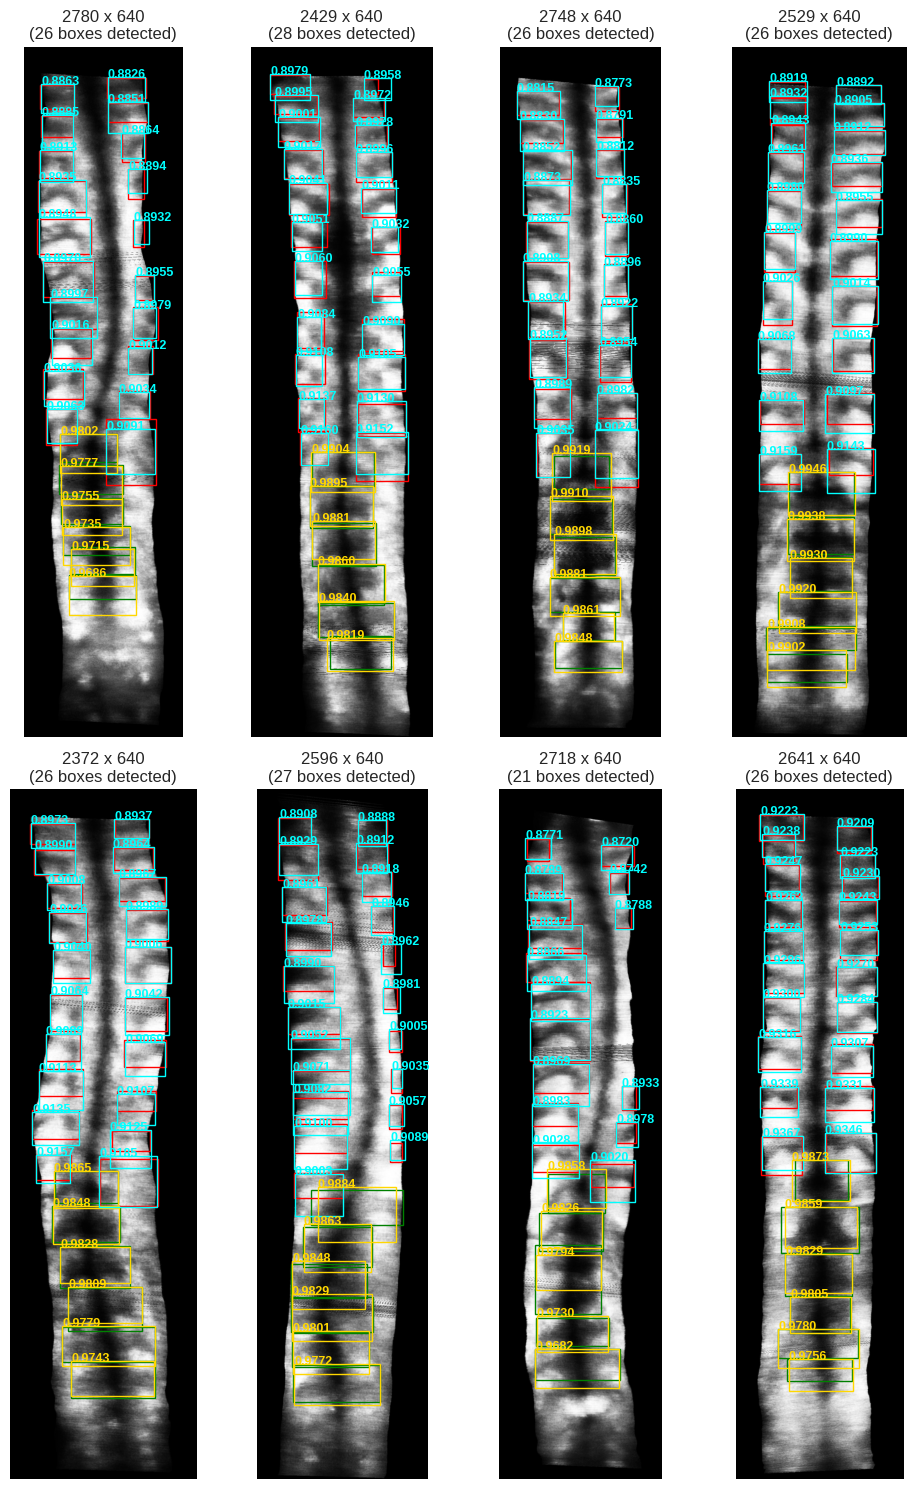

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(10, 15))
axes = axes.flatten()  # Flatten the grid for easy indexing
for ax in axes: ax.grid(False) # Turn off gridlines
grid_idx, pred_prid_idx = 0, 0 # Counter for the grid positions

for names, images, targets in val_loader:
    images, targets, boxes_by_images, labels_by_images, all_boxes, all_labels = concat_batch(images, targets, device)
    pred_boxes, pred_labels, _ = model(images, all_boxes, boxes_by_images)
    pred_labels = F.softmax(pred_labels, dim=-1)
    scores, pred_labels_idxs = pred_labels.max(dim=1)

    # Reshape to match boxes_by_images shape
    pred_boxes_by_images = torch.split(pred_boxes, [len(b) for b in boxes_by_images])
    pred_labels_by_images = torch.split(pred_labels_idxs, [len(b) for b in boxes_by_images])
    scores_by_images = torch.split(scores, [len(b) for b in boxes_by_images])

    # Plot each ground truth box
    for name, boxes, labels in zip(names, boxes_by_images, labels_by_images):
        if grid_idx >= len(axes): break # Stop if all subplots are filled
        image = Image.open(images_dir / f'{name}.jpg')
        scale_x, scale_y = get_scale(image) # Scale the boxes back to the original image dimensions
        orig_width, orig_height = image.size

        # Display image
        axes[grid_idx].imshow(image, cmap='gray')
        axes[grid_idx].axis('off') # Turn off axis labels and ticks
        axes[grid_idx].set_title(f'{orig_height} x {orig_width}\n({len(boxes)} boxes detected)')
        grid_idx += 1  # Move to the next subplot position

        for box, label in zip(boxes, labels):
            if label >= 2: continue
            x1, y1, x2, y2 = box.cpu().numpy()
            x1, y1, x2, y2 = x1 * scale_x, y1 * scale_y, x2 * scale_x, y2 * scale_y
            color = 'red' if label == 0 else 'green'
            rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=1, edgecolor=color, facecolor='none')
            axes[grid_idx - 1].add_patch(rect) # Add the rectangle to the plot

    # Plot each predicted box (Similar processing as for ground truth boxes)
    for name, boxes, labels, scores in zip(names, pred_boxes_by_images, pred_labels_by_images, scores_by_images):
        if pred_prid_idx >= len(axes): break # Stop if all subplots are filled
        image = Image.open(images_dir / f'{name}.jpg')
        scale_x, scale_y = get_scale(image) # Scale the boxes back to the original image dimensions
        pred_prid_idx += 1  # Move to the next subplot position

        for box, label, score in zip(boxes, labels, scores):
            if label >= 2: continue
            x1, y1, x2, y2 = box.cpu().detach().numpy() # Detach the tensor before converting to NumPy
            x1, y1, x2, y2 = x1 * scale_x, y1 * scale_y, x2 * scale_x, y2 * scale_y
            color = 'cyan' if label == 0 else 'gold'
            rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=1, edgecolor=color, facecolor='none')
            axes[pred_prid_idx - 1].add_patch(rect) # Add the rectangle to the plot
            axes[pred_prid_idx - 1].text(
                x1, y1, f'{score.cpu().detach().numpy():.4f}',
                fontsize=9, fontweight='bold',
                color=color, # bbox=dict(facecolor='white', alpha=0.2)
            )
    if grid_idx >= len(axes): break # Stop if all subplots are filled

for ax in axes[grid_idx:]: ax.axis('off') # Hide any unused subplots
plt.tight_layout()
plt.show()